# Energy Regression
Play around with a BDT for energy regression, starting from Nik's notebook `paramhist_SIMS.ipynb`. Currently the core distance calculation is set for the triangle observations at Lick.

# Imports

In [8]:
# imports
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import os
from pathlib import Path

# for BDT
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

# for regression BDT
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import seaborn as sns

# Read Data

## Data files

In [11]:
# read data
base_dir = os.getcwd()
base_dir = Path(base_dir)
data_path = base_dir / "testdata/gamma_Lick_100K_zen00_az0.csv"
print(data_path)

df1 = pd.read_csv(data_path)

/Users/elisa/Desktop/Dark100/NiksPipeline/PANOSETI-High-Energy-Analysis-Pipeline/analysis-tools/testdata/gamma_Lick_100K_zen00_az0.csv


## Cleaning data

In [12]:
# remove nans
array1=df1.dropna(subset=["Length", "Width","Miss","Distance","Azwidth","Alpha"])
array1=array1[array1["Width"]>0]
#array1.head()

In [13]:
array1.describe()

,Event,Telescope,MeanX,StdX,MeanY,StdY,Phi,Size,Length,Width,...,Az,Ze,Xcore,Ycore,stdP,TrueAz,TrueZe,TrueXcore,TrueYcore,TrueEnergy
count,65319.000000,65319.000000,65319.000000,65319.000000,65319.000000,65319.000000,65319.000000,65319.000000,65319.000000,6.531900e+04,...,41751.000000,41751.000000,41751.000000,41751.000000,4.175100e+04,6.531900e+04,65319.0,65319.000000,65319.000000,65319.000000
mean,50113.891272,1.977143,-0.008203,0.320431,-0.018092,0.315697,180.966937,5081.959813,0.416649,1.966173e-01,...,180.332496,0.324276,-4.469712,2.208489,2.537782e+02,1.277000e+01,0.0,-0.639105,4.264025,52734.872052
std,28840.680801,0.813675,0.948267,0.135676,0.931962,0.132710,137.992822,7802.961139,0.156780,3.906850e-02,...,103.842437,1.978136,897.767203,501.114216,2.489220e+04,1.133502e-11,0.0,98.205226,99.939049,48749.797384
min,2.000000,1.000000,-3.800580,0.087017,-3.307990,0.051188,0.000000,117.000000,0.143841,3.725290e-09,...,0.033098,0.000464,-102741.000000,-54845.500000,0.000000e+00,1.277000e+01,0.0,-199.981000,-199.999000,2020.950000
25%,25267.000000,1.000000,-0.747953,0.219330,-0.755689,0.217358,43.877000,1222.000000,0.291218,1.726425e-01,...,90.768100,0.051069,-64.866200,-68.952850,1.537755e-10,1.277000e+01,0.0,-76.249000,-71.158200,15111.950000
50%,50265.000000,2.000000,-0.016700,0.282511,-0.046077,0.278375,270.846000,2378.000000,0.387696,1.976130e-01,...,181.006000,0.101917,-5.862830,8.233400,5.929220e-04,1.277000e+01,0.0,-1.414400,4.155680,33113.700000
75%,74972.000000,3.000000,0.736464,0.390246,0.693534,0.383590,315.518500,5448.000000,0.518146,2.193625e-01,...,269.940000,0.214401,75.258400,66.075200,2.074180e+01,1.277000e+01,0.0,74.445150,83.770600,76190.800000
max,100000.000000,3.000000,3.620400,1.056570,3.336100,1.048030,360.000000,172995.000000,1.284690,7.221930e-01,...,359.995000,86.388500,31554.800000,11961.400000,3.576260e+06,1.277000e+01,0.0,199.959000,199.936000,199976.000000


# Image Parameter Distributions

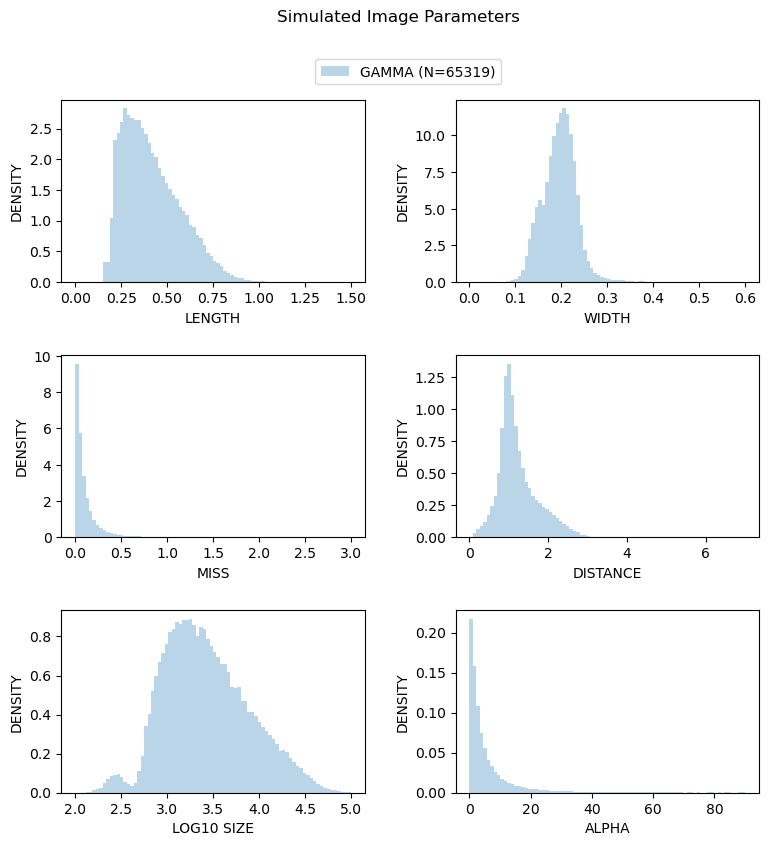

In [14]:
fig, axs = plt.subplots(3,2, figsize=(9,9))

fig.suptitle('Simulated Image Parameters')

# select subset of showers which are nearby
# array1 = array1[np.hypot(array1["TrueXcore"].values,array1["TrueYcore"].values) < 200]
# array2 = array2[np.hypot(array2["TrueXcore"].values,array2["TrueYcore"].values) < 200]

# cut showers by distance
# array1 = array1[array1["Distance"].values < 2]
# array2 = array2[array2["Distance"].values < 2]

# cut showers by alpha
# array1 = array1[array1["Alpha"].values > 10]
# array2 = array2[array2["Alpha"].values > 10]

# cut showers by size
# array1 = array1[array1["Size"].values > 10**3]
# array2 = array2[array2["Size"].values > 10**3]

axs[0,0].hist(array1.loc[:,"Length"], alpha=0.3, bins=80, range=(0,1.5), label='GAMMA (N={:.0f})'.format(len(array1)),density=True)
axs[0,0].set(xlabel='LENGTH')
axs[0,1].hist(array1.loc[:,"Width"], alpha=0.3, bins=80, range=(0,0.6),density=True)
axs[0,1].set(xlabel='WIDTH')
axs[1,0].hist(array1.loc[:,"Miss"], alpha=0.3, bins=80, range=(0,3),density=True)
axs[1,0].set(xlabel='MISS')
axs[1,1].hist(array1.loc[:,"Distance"], alpha=0.3, bins=80, range=(0,7),density=True)
axs[1,1].set(xlabel='DISTANCE')
# axs[2,0].hist(array1.loc[:,"Azwidth"], alpha=0.3, bins=80, range=(0,1),density=True)
# axs[2,0].hist(array2.loc[:,"Azwidth"], alpha=0.5, bins=80, range=(0,1),density=True)
# axs[2,0].set(xlabel='AZWIDTH')
# axs[2,0].hist(array1.loc[:,"Size"], alpha=0.3, bins=80, range=(0,1e3),density=True)
# axs[2,0].hist(array2.loc[:,"Size"], alpha=0.5, bins=80, range=(0,1e3),density=True)
axs[2,0].set(xlabel='Size')
axs[2,0].hist(np.log10(array1.loc[:,"Size"]), alpha=0.3, bins=80, range=(2,5),density=True)
axs[2,0].set(xlabel='LOG10 SIZE')
axs[2,1].hist(array1.loc[:,"Alpha"], alpha=0.3, bins=80, range=(0,90),density=True)
axs[2,1].set(xlabel='ALPHA')

for ax in axs.flat:
    # ax.set(ylabel='POPULATION (normalized)')
    ax.set(ylabel='DENSITY')

plt.subplots_adjust(hspace=0.4,wspace=0.3)
fig.legend(loc=(0.41,0.9))

In [15]:
array1.head()

,Event,Telescope,MeanX,StdX,MeanY,StdY,Phi,Size,Length,Width,...,Az,Ze,Xcore,Ycore,stdP,TrueAz,TrueZe,TrueXcore,TrueYcore,TrueEnergy
0,99001,1,-0.920814,0.222310,-0.152680,0.180418,3.99103,1079,0.222496,0.180189,...,NaN,NaN,NaN,NaN,NaN,12.77,0,-177.8630,95.2171,12630.5
10,99004,2,0.890103,0.334923,0.753006,0.277701,36.39910,2559,0.392319,0.188089,...,NaN,NaN,NaN,NaN,NaN,12.77,0,140.9550,-24.7474,19578.0
15,99006,1,1.114590,0.452063,0.110260,0.230374,7.07897,8607,0.454677,0.225172,...,277.076,0.011038,9.7456,23.052,449.708,12.77,0,17.9075,23.2407,68218.3
16,99006,2,-0.776441,0.419499,0.615795,0.348197,323.38900,9579,0.493383,0.231934,...,277.076,0.011038,9.7456,23.052,449.708,12.77,0,17.9075,23.2407,68218.3
17,99006,3,-0.044485,0.203251,-1.194030,0.569295,88.26990,6120,0.569522,0.202614,...,277.076,0.011038,9.7456,23.052,449.708,12.77,0,17.9075,23.2407,68218.3


# Calculate core distance

In [16]:
def get_telescope_X(n):
    if(n==3):
        return 126.65
    elif(n==1):
        return -101.35
    else:
        return -25.29

def get_telescope_Y(n):
    if(n==3):
        return -42.32
    elif(n==1):
        return -42.32
    else:
        return 84.64

In [17]:
array1["TelX"] = array1["Telescope"].apply(get_telescope_X)
array1["TelY"] = array1["Telescope"].apply(get_telescope_Y)

r1=np.hypot(array1["TrueXcore"]-array1["TelX"],array1["TrueYcore"]-array1["TelY"])
r1

0         157.387080
10        199.005033
15        136.090252
16         75.072618
17        126.976914
             ...    
299977    215.565830
299978     17.769799
299981    251.365062
299985     48.831600
299987    276.822046
Length: 65319, dtype: float64

# BDT for energy regression

## Set up regressor

In [18]:
gbr = GradientBoostingRegressor(
    n_estimators=500,       # number of boosting stages
    learning_rate=0.05,     # shrinkage (lower values need more trees)
    max_depth=4,            # depth of each regression tree
    subsample=0.8,          # stochastic gradient boosting
    random_state=42
)

## Create training set

In [19]:
data1 = array1[["Size","Length","Width", "TrueEnergy"]]

data1 = data1.dropna()

# combine data
X = pd.concat([data1])

X.head()

,Size,Length,Width,TrueEnergy
0,1079,0.222496,0.180189,12630.5
10,2559,0.392319,0.188089,19578.0
15,8607,0.454677,0.225172,68218.3
16,9579,0.493383,0.231934,68218.3
17,6120,0.569522,0.202614,68218.3


In [20]:
X.tail()

,Size,Length,Width,TrueEnergy
299977,4867,0.506480,0.189537,45182.90
299978,1559,0.391214,0.172168,45182.90
299981,289,0.262043,0.129986,4804.59
299985,4699,0.434458,0.195449,50440.10
299987,1714,0.456397,0.139523,50440.10


In [21]:
X.insert(1, "CoreDistance", r1)
X.head()

,Size,CoreDistance,Length,Width,TrueEnergy
0,1079,157.387080,0.222496,0.180189,12630.5
10,2559,199.005033,0.392319,0.188089,19578.0
15,8607,136.090252,0.454677,0.225172,68218.3
16,9579,75.072618,0.493383,0.231934,68218.3
17,6120,126.976914,0.569522,0.202614,68218.3


In [22]:
X.tail()

,Size,CoreDistance,Length,Width,TrueEnergy
299977,4867,215.565830,0.506480,0.189537,45182.90
299978,1559,17.769799,0.391214,0.172168,45182.90
299981,289,251.365062,0.262043,0.129986,4804.59
299985,4699,48.831600,0.434458,0.195449,50440.10
299987,1714,276.822046,0.456397,0.139523,50440.10


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X.iloc[:,:-1],X[["TrueEnergy"]], test_size=0.33, random_state=0)

In [24]:
X_train.head()

,Size,CoreDistance,Length,Width
86052,10020,205.117882,0.514029,0.220424
151944,2853,108.305867,0.350710,0.189308
88040,665,222.583280,0.218659,0.163365
214130,2937,103.925513,0.343515,0.228335
184999,2877,163.701217,0.349803,0.198273


In [25]:
y_train.head()

,TrueEnergy
86052,83738.0
151944,28569.8
88040,14222.5
214130,24480.2
184999,22183.3


In [26]:
X_test.head()

,Size,CoreDistance,Length,Width
257009,8647,203.823185,0.436426,0.212917
105763,1454,204.927750,0.316055,0.188076
259606,1846,114.644389,0.263083,0.209824
108167,1946,83.939015,0.536018,0.204717
149269,5995,196.717441,0.363962,0.203102


## Train BDTs

In [27]:
gbr.fit(X_train, y_train.values.ravel())
gbr.score(X_test, y_test.values.ravel())

0.7859127152060925

## Results

### Predict the energy of events

In [28]:
y_pred = gbr.predict(X_test)
y_pred

array([61833.18993376, 19609.25007087, 16018.76121162, ...,
       29471.07652799, 42658.99771158, 31796.70382282])

In [29]:
y_test.head()

,TrueEnergy
257009,49737.0
105763,18084.9
259606,14446.9
108167,114290.0
149269,43950.4


In [30]:
np.log10(y_test)

,TrueEnergy
257009,4.696680
105763,4.257316
259606,4.159775
108167,5.058008
149269,4.642963
...,...
147250,3.855142
31513,4.346402
146835,4.316425
102600,5.028848


(0.0, 200.0)

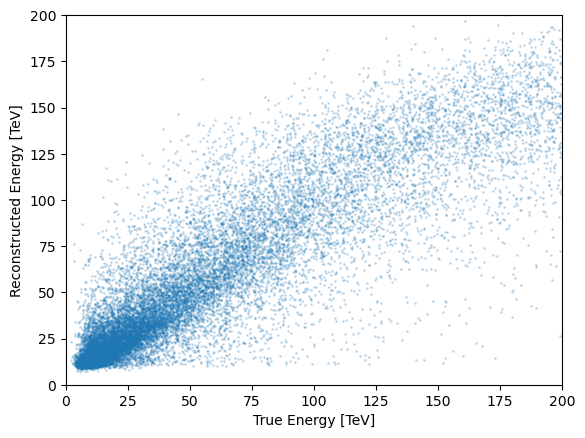

In [31]:
fig,axs = plt.subplots()
plt.xlabel('True Energy [TeV]')
plt.ylabel('Reconstructed Energy [TeV]')
axs.plot(y_test/1000.,y_pred/1000.,linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')
plt.xlim(0, 200)
plt.ylim(0, 200)

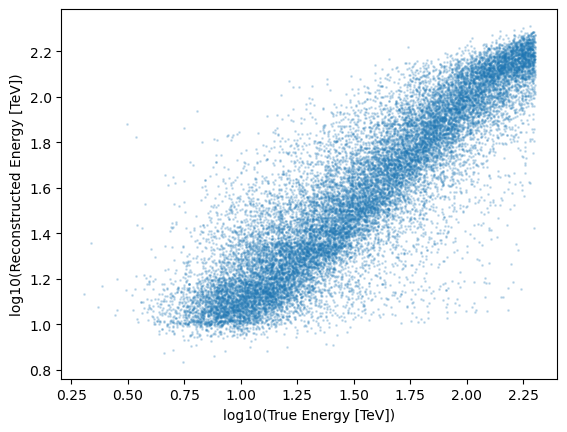

In [32]:
fig,axs = plt.subplots()
plt.xlabel('log10(True Energy [TeV])')
plt.ylabel('log10(Reconstructed Energy [TeV])')
axs.plot(np.log10(y_test/1000.),np.log10(y_pred/1000.),linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')

#plt.savefig('/Users/elisa/Desktop/Dark100/EnergyRegression/energy_scatterplot_100K.png',dpi=300)

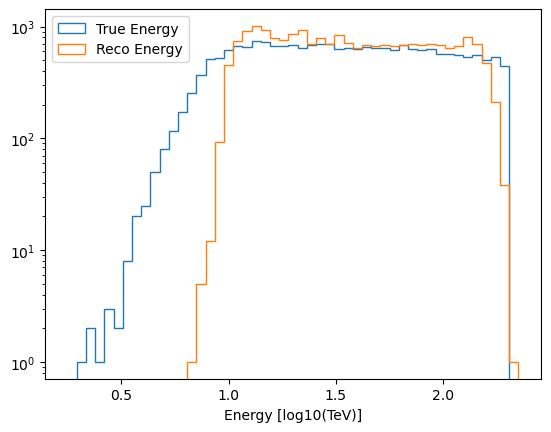

In [33]:
e_true_log10 = np.log10(y_test/1000.) 
e_rec_log10 = np.log10(y_pred/1000.)

bin_edges = np.linspace(0.25, 2.35, 50)  

plt.hist(e_true_log10, bins=bin_edges, histtype='step', label='True Energy')
plt.hist(e_rec_log10, bins=bin_edges, histtype='step', label='Reco Energy')
plt.xlabel('Energy [log10(TeV)]')
plt.yscale('log')

plt.legend();

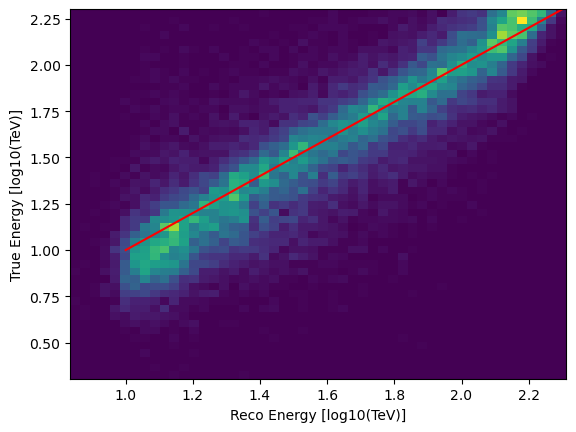

In [34]:
plt.hist2d(e_rec_log10, e_true_log10.values.ravel(), bins=50)
plt.xlabel('Reco Energy [log10(TeV)]')
plt.ylabel('True Energy [log10(TeV)]')

x = np.linspace(1.0, 3.0, 2) 
plt.plot(x, x, color='red')

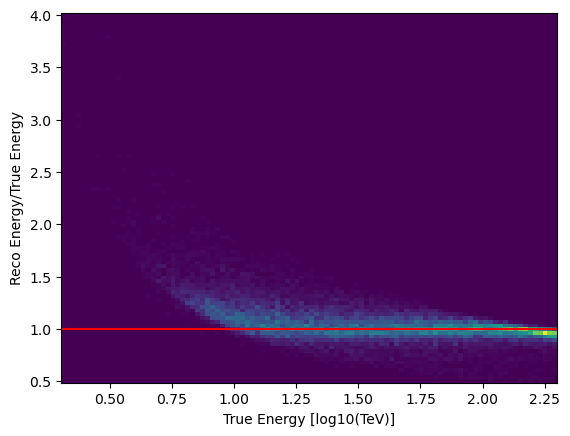

In [35]:
plt.hist2d(e_true_log10.values.ravel(), e_rec_log10/e_true_log10.values.ravel(), bins=100)
plt.xlabel('True Energy [log10(TeV)]')
plt.ylabel('Reco Energy/True Energy')

x = np.linspace(0.25, 2.35, 2)
y = np.linspace(1.0, 1.0, 2) # this is a stupid way to do it
plt.plot(x, y, color='red')

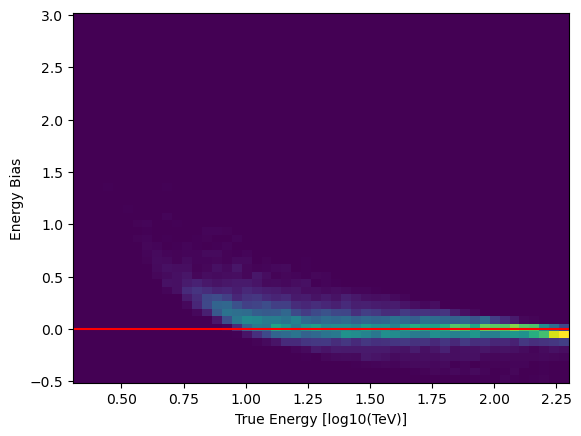

In [36]:
e_bias = (e_rec_log10 - e_true_log10.values.ravel())/e_true_log10.values.ravel()

plt.hist2d(e_true_log10.values.ravel(), e_bias, bins=50)
plt.xlabel('True Energy [log10(TeV)]')
plt.ylabel('Energy Bias')

x = np.linspace(0.25, 2.35, 2)
y = np.linspace(0.0, 0.0, 2) # this is a stupid way to do it
plt.plot(x, y, color='red')

## Energy Bias

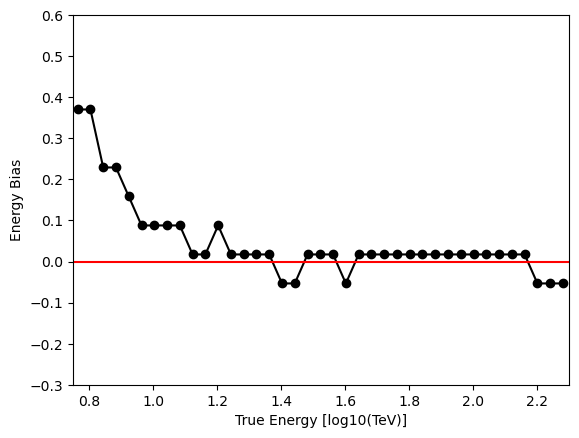

In [29]:
H, xedges, yedges = np.histogram2d(e_true_log10.values.ravel(), e_bias, bins=(50, 50))

max_indices = np.argmax(H, axis=1)

# xedges[:-1] is the array of lower edges
# xedges[1:] is the array of upper edges
# average to get bin centers
ycenters = 0.5 * (yedges[:-1] + yedges[1:])
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ymax_values = ycenters[max_indices]

#for xc, yc in zip(xcenters, ymax_values):
#    print(f"x = {xc:.2f}, max at y = {yc:.2f}")
plt.plot(xcenters, ymax_values, 'ko', linestyle='solid')
plt.xlim(0.75, 2.3)
plt.ylim(-0.3, 0.6)
plt.xlabel('True Energy [log10(TeV)]')
plt.ylabel('Energy Bias')

x = np.linspace(0.25, 2.35, 2)
y = np.linspace(0.0, 0.0, 2) # this is a stupid way to do it
plt.plot(x, y, color='red')

## Energy Resolution

(-0.3, 0.6)

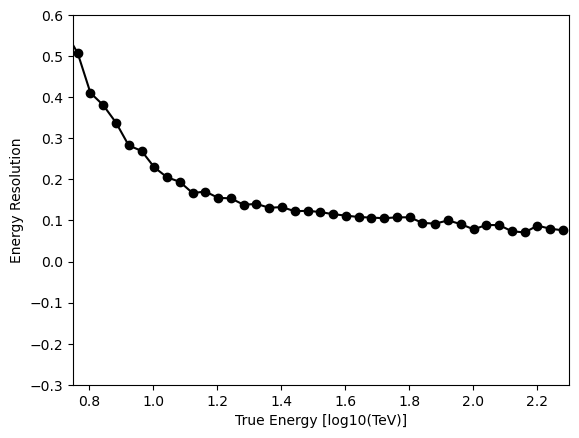

In [30]:
rms_y = []
for i in range(H.shape[0]):  # loop over x bins
    counts = H[i, :]

    if counts.sum() == 0:
        rms_y.append(np.nan)  # avoid division by zero
    else:
        mean_y2 = np.sum(counts * (ycenters**2)) / counts.sum()
        rms_y.append(np.sqrt(mean_y2))

rms_y = np.array(rms_y)

plt.plot(xcenters, rms_y, 'ko', linestyle='solid')
plt.xlabel('True Energy [log10(TeV)]')
plt.ylabel('Energy Resolution')
plt.xlim(0.75, 2.3)
plt.ylim(-0.3, 0.6)